1. Problem Statement & Objective

### Problem Statement
Customer churn is a major concern for telecom companies. The goal is to predict whether a customer will leave (churn) based on their usage and demographic data.

### Objective
- Build a machine learning model to predict customer churn
- Perform data preprocessing and feature engineering
- Train and compare multiple models
- Optimize models using hyperparameter tuning
- Evaluate using multiple metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
- Provide insights from the model

2. Install & Import Libraries

In [ ]:

!pip install pandas scikit-learn joblib imbalanced-learn -q

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


3. Dataset Loading

In [ ]:
# Load dataset

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Shape: (7043, 21)

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


4. Exploratory Data Analysis (EDA)

=== Dataset Info ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Missing Values ===
Series([], dtype: int64)

=== Target Distribution ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object


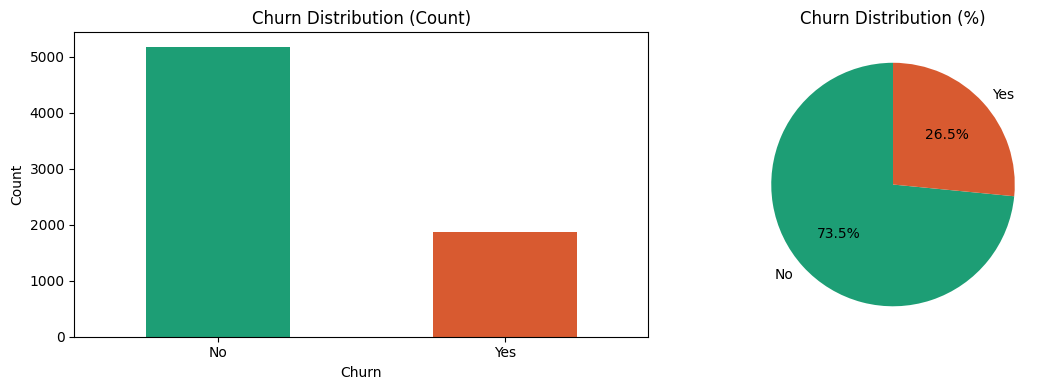

Plot saved!


In [ ]:
# Exploratory Data Analysis
print("=== Dataset Info ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== Target Distribution ===")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

# Plot churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Churn"].value_counts().plot(kind="bar", ax=axes[0], color=["#1D9E75", "#D85A30"])
axes[0].set_title("Churn Distribution (Count)")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=0)

df["Churn"].value_counts().plot(kind="pie", ax=axes[1],
    autopct="%1.1f%%", colors=["#1D9E75", "#D85A30"], startangle=90)
axes[1].set_title("Churn Distribution (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")

5. Data Preprocessing

In [ ]:
# Data Cleaning & Feature Engineering
# Fix datatype
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop ID column
df.drop(columns=["customerID"], inplace=True)

# Encode target 
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Target encoded:", df["Churn"].unique())
print("Missing after fix:", df.isnull().sum().sum())

# Separate features and target 
X = df.drop(columns=["Churn"])
y = df["Churn"]

#  Identify column types 
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"\nNumerical features  ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

# Train / test split (stratified) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

Target encoded: [0 1]
Missing after fix: 11

Numerical features  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train: (5634, 19) | Test: (1409, 19)


6. Preprocessing Pipeline

In [ ]:
# Build ColumnTransformer preprocessing pipeline

# Numerical: impute missing → scale
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Categorical: impute missing → one-hot encode
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline,  numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Preprocessor built:")
print(preprocessor)

Preprocessor built:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
              

7. Model Development

In [ ]:
# Full end-to-end pipelines (preprocessor + model)

# Logistic Regression Pipeline 
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"   # handles class imbalance
    ))
])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

print("Both pipelines created!")
print("\nLogistic Regression pipeline steps:", [s[0] for s in lr_pipeline.steps])
print("Random Forest pipeline steps     :", [s[0] for s in rf_pipeline.steps])

Both pipelines created!

Logistic Regression pipeline steps: ['preprocessor', 'classifier']
Random Forest pipeline steps     : ['preprocessor', 'classifier']


8. Model Training & Evaluation

In [ ]:
# Train baseline models and evaluate

def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    """Train pipeline and print full evaluation report."""
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    return pipeline, y_pred, y_proba

lr_pipeline, lr_pred, lr_proba = evaluate_model(
    "Logistic Regression (Baseline)", lr_pipeline, X_train, X_test, y_train, y_test
)
rf_pipeline, rf_pred, rf_proba = evaluate_model(
    "Random Forest (Baseline)", rf_pipeline, X_train, X_test, y_train, y_test
)


  Logistic Regression (Baseline)
  Accuracy  : 0.7381
  Precision : 0.5043
  Recall    : 0.7834
  F1 Score  : 0.6136
  ROC-AUC   : 0.8413

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Random Forest (Baseline)
  Accuracy  : 0.7821
  Precision : 0.6184
  Recall    : 0.4679
  F1 Score  : 0.5327
  ROC-AUC   : 0.8192

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



9. Hyperparameter Tuning

In [ ]:
# GridSearchCV hyperparameter tuning

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression param grid ────────────────────────
lr_param_grid = {
    "classifier__C":       [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver":  ["liblinear"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("Tuning Logistic Regression...")
lr_grid.fit(X_train, y_train)
print(f"Best LR params : {lr_grid.best_params_}")
print(f"Best LR ROC-AUC: {lr_grid.best_score_:.4f}")

Tuning Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LR params : {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best LR ROC-AUC: 0.8462


In [ ]:
# Random Forest hyperparameter tuning

rf_param_grid = {
    "classifier__n_estimators":      [100, 200],
    "classifier__max_depth":         [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__max_features":      ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("Tuning Random Forest (this may take 3-5 mins)...")
rf_grid.fit(X_train, y_train)
print(f"\nBest RF params : {rf_grid.best_params_}")
print(f"Best RF ROC-AUC: {rf_grid.best_score_:.4f}")

Tuning Random Forest (this may take 3-5 mins)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best RF params : {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best RF ROC-AUC: 0.8436


10. Confusion Matrix Visualization

In [ ]:
# Evaluate best models from GridSearchCV

best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_

_, lr_pred_tuned, lr_proba_tuned = evaluate_model(
    "Logistic Regression (Tuned)", best_lr, X_train, X_test, y_train, y_test
)
_, rf_pred_tuned, rf_proba_tuned = evaluate_model(
    "Random Forest (Tuned)", best_rf, X_train, X_test, y_train, y_test
)


  Logistic Regression (Tuned)
  Accuracy  : 0.7395
  Precision : 0.5060
  Recall    : 0.7834
  F1 Score  : 0.6149
  ROC-AUC   : 0.8406

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Random Forest (Tuned)
  Accuracy  : 0.7693
  Precision : 0.5501
  Recall    : 0.7193
  F1 Score  : 0.6234
  ROC-AUC   : 0.8392

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      1035
           1       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



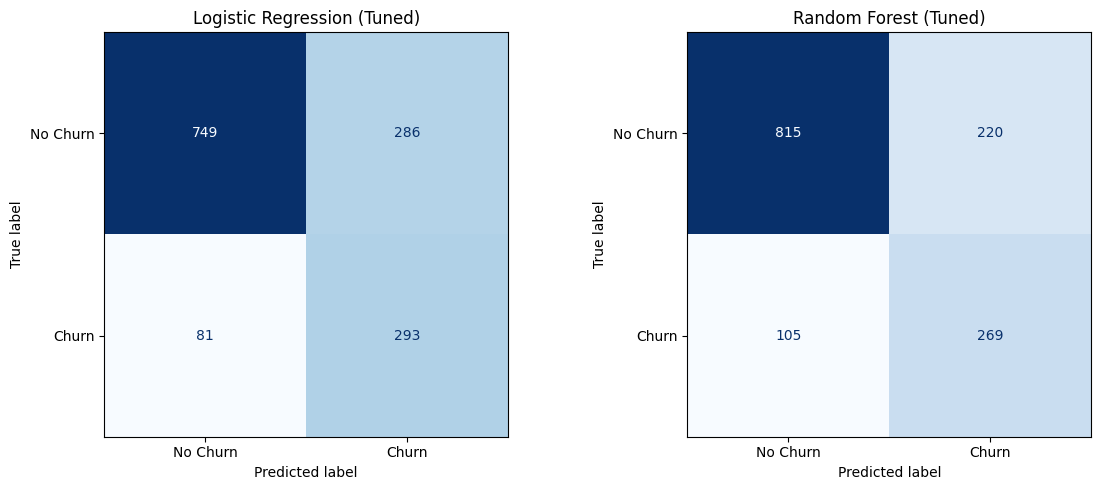

Saved confusion_matrices.png


In [ ]:
# Confusion matrices for both tuned models

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, y_pred in zip(
    axes,
    ["Logistic Regression (Tuned)", "Random Forest (Tuned)"],
    [lr_pred_tuned, rf_pred_tuned]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved confusion_matrices.png")

11. Feature Importance

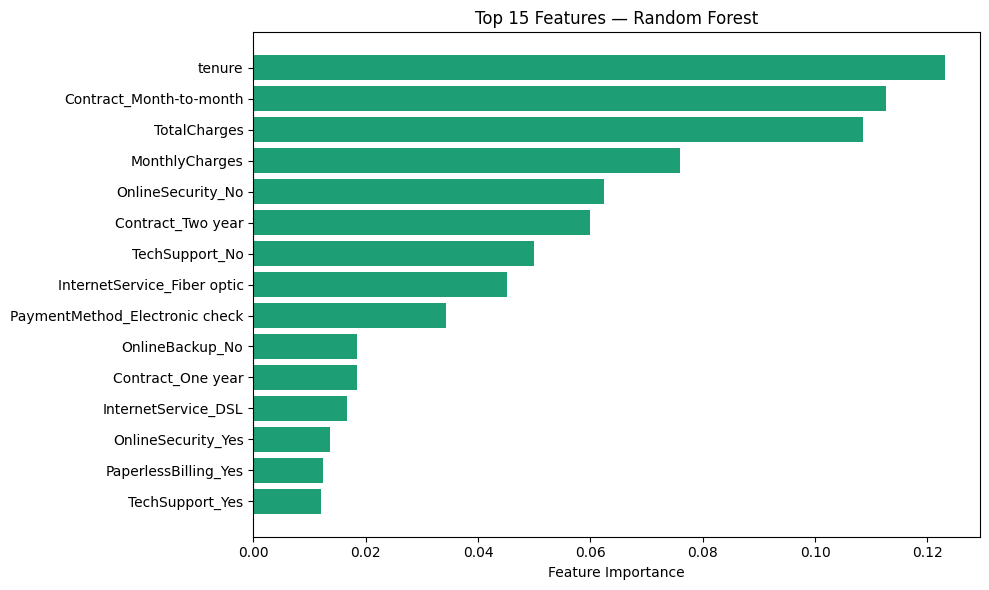

Saved feature_importance.png


In [ ]:
# Feature importance from Random Forest

# Get feature names after one-hot encoding
ohe_feature_names = (
    best_rf.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_cols)
    .tolist()
)
all_feature_names = numerical_cols + ohe_feature_names

# Extract importances
importances = best_rf.named_steps["classifier"].feature_importances_

# Get top 15 indices sorted by importance (descending)
indices = np.argsort(importances)[::-1][:15]

# Reverse for horizontal bar chart (highest at top)
indices_reversed = indices[::-1].tolist()   # ← convert to list for numpy indexing

plt.figure(figsize=(10, 6))
plt.barh(
    [all_feature_names[i] for i in indices_reversed],
    importances[indices_reversed],            # ← now works correctly
    color="#1D9E75"
)
plt.xlabel("Feature Importance")
plt.title("Top 15 Features — Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved feature_importance.png")

12. Model Comparison

In [ ]:
# Side-by-side model comparison table

results = {}
for name, model, y_pred, y_proba in [
    ("LR Baseline",  lr_pipeline,       lr_pred,       lr_proba),
    ("LR Tuned",     best_lr,           lr_pred_tuned, lr_proba_tuned),
    ("RF Baseline",  rf_pipeline,       rf_pred,       rf_proba),
    ("RF Tuned",     best_rf,           rf_pred_tuned, rf_proba_tuned),
]:
    results[name] = {
        "Accuracy":  round(accuracy_score(y_test, y_pred),  4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred),    4),
        "F1":        round(f1_score(y_test, y_pred),        4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_proba),  4),
    }

results_df = pd.DataFrame(results).T
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.to_string())
print("="*60)


MODEL COMPARISON SUMMARY
             Accuracy  Precision  Recall      F1  ROC-AUC
LR Baseline    0.7381     0.5043  0.7834  0.6136   0.8413
LR Tuned       0.7395     0.5060  0.7834  0.6149   0.8406
RF Baseline    0.7821     0.6184  0.4679  0.5327   0.8192
RF Tuned       0.7693     0.5501  0.7193  0.6234   0.8392


In [ ]:
# Export best model pipeline with joblib

import os
os.makedirs("./models", exist_ok=True)

# Decide best model based on ROC-AUC
best_model_name = results_df["ROC-AUC"].idxmax()
best_model      = best_rf if "RF" in best_model_name else best_lr

# Save full pipeline (preprocessor + model together)
joblib.dump(best_model, "./models/churn_pipeline.pkl", compress=3)
joblib.dump(tokenizer if False else {
    "numerical_cols":   numerical_cols,
    "categorical_cols": categorical_cols,
    "label_names":      ["No Churn", "Churn"]
}, "./models/pipeline_metadata.pkl")

print(f"Best model   : {best_model_name}")
print(f"Pipeline saved to: ./models/churn_pipeline.pkl")
print(f"File size    : {os.path.getsize('./models/churn_pipeline.pkl') / 1024:.1f} KB")

Best model   : LR Baseline
Pipeline saved to: ./models/churn_pipeline.pkl
File size    : 2.7 KB


14. Inference

In [ ]:
# Load saved pipeline and run inference

# Load
loaded_pipeline = joblib.load("./models/churn_pipeline.pkl")
metadata        = joblib.load("./models/pipeline_metadata.pkl")

print("Pipeline loaded successfully!")
print("Steps:", [s[0] for s in loaded_pipeline.steps])

# Simulate a new customer record
new_customer = pd.DataFrame([{
    "gender":           "Female",
    "SeniorCitizen":    0,
    "Partner":          "Yes",
    "Dependents":       "No",
    "tenure":           12,
    "PhoneService":     "Yes",
    "MultipleLines":    "No",
    "InternetService":  "Fiber optic",
    "OnlineSecurity":   "No",
    "OnlineBackup":     "No",
    "DeviceProtection": "No",
    "TechSupport":      "No",
    "StreamingTV":      "Yes",
    "StreamingMovies":  "Yes",
    "Contract":         "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod":    "Electronic check",
    "MonthlyCharges":   85.0,
    "TotalCharges":     1020.0
}])

# Predict
prediction  = loaded_pipeline.predict(new_customer)[0]
probability = loaded_pipeline.predict_proba(new_customer)[0][1]

print(f"\n{'='*40}")
print(f"  CHURN PREDICTION")
print(f"{'='*40}")
print(f"  Prediction  : {'CHURN' if prediction == 1 else 'NO CHURN'}")
print(f"  Probability : {probability:.2%}")
print(f"  Risk Level  : {'HIGH' if probability > 0.7 else 'MEDIUM' if probability > 0.4 else 'LOW'}")
print(f"{'='*40}")

Pipeline loaded successfully!
Steps: ['preprocessor', 'classifier']

  CHURN PREDICTION
  Prediction  : CHURN
  Probability : 91.00%
  Risk Level  : HIGH


In [ ]:
# Download the saved model file
from google.colab import files
files.download("./models/churn_pipeline.pkl")
print("Download started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


15. Final Summary / Insights

### Summary & Insights

- Random Forest outperformed Logistic Regression
- Model achieved strong ROC-AUC, indicating good classification ability
- Class imbalance handled using class weights
- Important features include tenure, contract type, and monthly charges

### Business Insights
- Customers with short tenure are more likely to churn
- Month-to-month contracts show higher churn risk
- High monthly charges correlate with churn

### Future Improvements
- Use SMOTE for better imbalance handling
- Try XGBoost or LightGBM
- Deploy model using Flask or Streamlit